# Module 9 — Correlation & Simple Linear Regression

**Statistics Deep Dive · Notebook 9 of 13**

So far we compared groups. Now both variables are numeric: *how strongly* do they move together (correlation), and *by how much* does one change when the other changes (regression)? Linear regression is the workhorse of applied statistics — almost everything in Modules 10–13 is built on it.

### 🎯 Learning goals
After this module you can …
1. compute and interpret **covariance, Pearson, Spearman and Kendall** correlation — and list what $r$ does *not* tell you,
2. explain **confounding** and compute a **partial correlation**,
3. derive, fit and interpret a **least-squares line** (slope, intercept, $R^2$, residual standard error),
4. quantify uncertainty: slope CI, **confidence band** vs. **prediction band**, and the danger of extrapolation,
5. check the model assumptions with **diagnostic plots** and repair violations by transformation.

### 🗺️ Contents
1. Covariance & correlation · 2. What $r$ does not tell you · 3. Inference for $r$ · 4. Correlation ≠ causation · 5. The least-squares line · 6. Reading the regression output · 7. $R^2$ · 8. Confidence & prediction bands · 9. Diagnostics & transformations · 10. Exercises · 11. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf

def diagnostic_plots(model, axes):
    """The four standard diagnostic plots for a fitted statsmodels OLS model (axes: 4 matplotlib axes)."""
    infl = model.get_influence(); fitted, resid = model.fittedvalues, model.resid
    std_resid, leverage = infl.resid_studentized_internal, infl.hat_matrix_diag
    lowess = sm.nonparametric.lowess
    axes[0].scatter(fitted, resid, s=14, alpha=.6); axes[0].plot(*lowess(resid, fitted, frac=.6).T, color=C[3], lw=2); axes[0].axhline(0, color="k", ls="--", lw=1)
    axes[0].set(title="Residuals vs fitted\n(linearity: is the red line flat?)", xlabel="fitted value", ylabel="residual")
    sm.qqplot(std_resid, line="45", ax=axes[1], markersize=3.5); axes[1].set_title("Normal Q–Q\n(normal errors: points on the line?)")
    axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), s=14, alpha=.6); axes[2].plot(*lowess(np.sqrt(np.abs(std_resid)), fitted, frac=.6).T, color=C[3], lw=2)
    axes[2].set(title="Scale–location\n(constant spread: is the red line flat?)", xlabel="fitted value", ylabel="√|standardised residual|")
    axes[3].scatter(leverage, std_resid, s=14 + 600 * infl.cooks_distance[0], alpha=.6); axes[3].axhline(0, color="k", ls="--", lw=1)
    axes[3].set(title="Residuals vs leverage\n(bubble size = Cook's distance)", xlabel="leverage", ylabel="standardised residual")
    for ax in axes: ax.title.set_fontsize(9.5)

---
## 1. Covariance & correlation — do two variables move together?

$$\operatorname{cov}(x,y)=\frac{1}{n-1}\sum_{i}(x_i-\bar x)(y_i-\bar y) \qquad\qquad r = \frac{\operatorname{cov}(x,y)}{s_x\,s_y}\in[-1,\,1]$$

**Intuition.** Split the scatterplot into four quadrants at $(\bar x,\bar y)$. A point in the upper-right or lower-left quadrant has a **positive** product of deviations, a point in the other two a **negative** one. The covariance is the average of these products (the signed rectangle areas in the figure). It depends on the units (k€ × m²…); dividing by both standard deviations gives the unit-free **Pearson correlation** $r$, a measure of **linear** association.

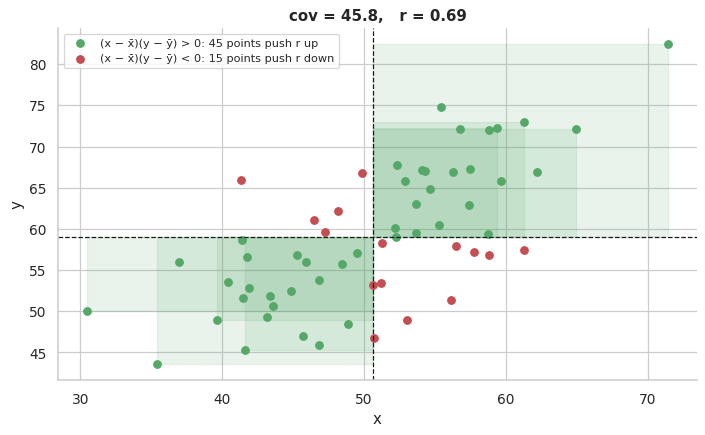

In [2]:
x = rng.normal(50, 10, 60); y = 20 + .8 * x + rng.normal(0, 8, 60)
dx, dy = x - x.mean(), y - y.mean(); pos = dx * dy > 0
fig, ax = plt.subplots(figsize=(8, 5))
for i in np.argsort(-np.abs(dx * dy))[:8]:                                   # draw the 8 largest products as rectangles
    ax.add_patch(plt.Rectangle((x.mean(), y.mean()), dx[i], dy[i], color=C[2] if pos[i] else C[3], alpha=.13))
ax.scatter(x[pos], y[pos], color=C[2], label=f"(x − x̄)(y − ȳ) > 0: {pos.sum()} points push r up")
ax.scatter(x[~pos], y[~pos], color=C[3], label=f"(x − x̄)(y − ȳ) < 0: {(~pos).sum()} points push r down")
ax.axvline(x.mean(), color="k", ls="--", lw=1); ax.axhline(y.mean(), color="k", ls="--", lw=1)
ax.set(xlabel="x", ylabel="y", title=f"cov = {np.cov(x, y)[0, 1]:.1f},   r = {np.corrcoef(x, y)[0, 1]:.2f}"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

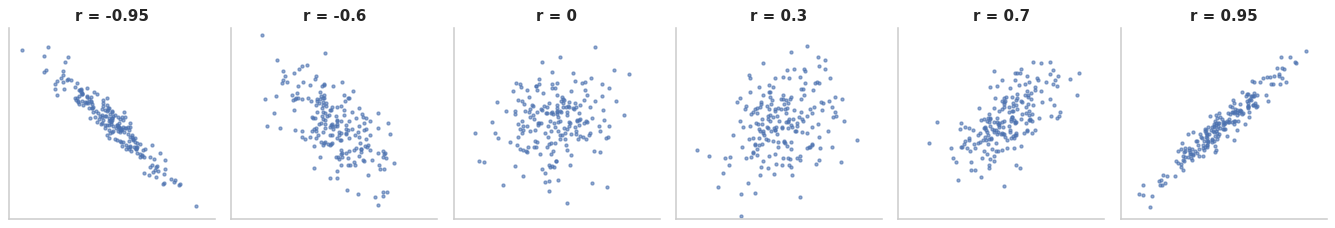

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(15, 2.7))
for ax, r in zip(axes, [-.95, -.6, 0, .3, .7, .95]):
    pts = rng.multivariate_normal([0, 0], [[1, r], [r, 1]], 200)
    ax.scatter(*pts.T, s=6, alpha=.6, color=C[0]); ax.set(xticks=[], yticks=[], xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), title=f"r = {r}")
plt.tight_layout(); plt.show()

**Calibrate your eye.** $r = 0.3$ is barely visible; even $r = 0.7$ leaves a lot of scatter. A handy translation: $r^2$ is the share of variance of one variable that is "explained" by a linear function of the other — $r=0.7$ means only 49 %.

---
## 2. What $r$ does *not* tell you

$r$ compresses a whole scatterplot into one number. Four classic ways in which that number misleads — each panel reports **Pearson's $r$** and **Spearman's $\rho$** (Pearson correlation of the *ranks*, which measures *monotonic* association and is robust to outliers; Kendall's $\tau$ is a related rank measure based on concordant pairs).

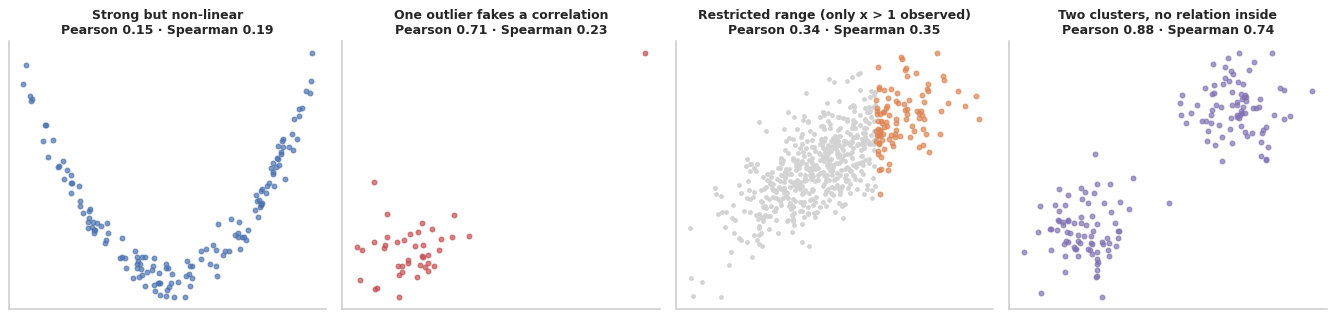

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.7))
def show(ax, x, y, title, **kw):
    ax.scatter(x, y, s=14, alpha=.7, **kw); ax.set(xticks=[], yticks=[])
    ax.set_title(f"{title}\nPearson {stats.pearsonr(x, y)[0]:.2f} · Spearman {stats.spearmanr(x, y)[0]:.2f}", fontsize=10)

x = rng.uniform(-3, 3, 150); show(axes[0], x, x ** 2 + rng.normal(0, .5, 150), "Strong but non-linear", color=C[0])
x = rng.normal(0, 1, 40); y = rng.normal(0, 1, 40); show(axes[1], np.append(x, 9), np.append(y, 9), "One outlier fakes a correlation", color=C[3])
x = rng.normal(0, 1, 600); y = .7 * x + rng.normal(0, .7, 600); keep = x > 1
axes[2].scatter(x[~keep], y[~keep], s=8, color="lightgrey"); show(axes[2], x[keep], y[keep], "Restricted range (only x > 1 observed)", color=C[1])
x = np.r_[rng.normal(0, 1, 80), rng.normal(6, 1, 80)]; y = np.r_[rng.normal(0, 1, 80), rng.normal(5, 1, 80)]; show(axes[3], x, y, "Two clusters, no relation inside", color=C[4])
plt.tight_layout(); plt.show()

**Reading the figure.** (1) $r\approx0$ does **not** mean "no relationship" — only "no *linear* relationship". (2) A single point can create (or destroy) a correlation; Spearman is far less impressed. (3) **Range restriction**: among the people you hired, the admission-test score barely predicts performance — because you only see the top of the range (grey: the full population). (4) Mixing heterogeneous groups produces correlation without any relationship inside the groups. **Always look at the scatterplot first.**

Two more facts worth remembering: $r$ says nothing about the **slope** (a steep and a flat line can both have $r=0.9$), and $r$ is symmetric — it does not know which variable is cause and which is effect.

---
## 3. Inference for a correlation

* **Test of $H_0:\rho=0$:** $\;t = r\sqrt{\dfrac{n-2}{1-r^2}}\sim t_{n-2}$ (this is what `stats.pearsonr` reports; it is identical to the slope test in regression).
* **Confidence interval:** $r$ has a skewed sampling distribution, so we use **Fisher's $z$-transformation** $z=\operatorname{arctanh}(r)$, which is approximately normal with $\operatorname{SE}=1/\sqrt{n-3}$, and transform back. Or bootstrap the *pairs*.

In [5]:
x = rng.normal(0, 1, 30); y = .5 * x + rng.normal(0, .9, 30)
res = stats.pearsonr(x, y); r = res.statistic
z, se = np.arctanh(r), 1 / np.sqrt(x.size - 3)
idx = rng.integers(0, x.size, (5000, x.size)); boot = np.array([np.corrcoef(x[i], y[i])[0, 1] for i in idx])
print(f"r = {r:.3f}, p = {res.pvalue:.4f}  (n = 30)")
print(f"95 % CI via Fisher z : [{np.tanh(z - 1.96 * se):.3f}, {np.tanh(z + 1.96 * se):.3f}]")
print(f"95 % CI via bootstrap: [{np.quantile(boot, .025):.3f}, {np.quantile(boot, .975):.3f}]   <- note how wide: n = 30 pins r down only roughly")

r = 0.628, p = 0.0002  (n = 30)
95 % CI via Fisher z : [0.346, 0.806]
95 % CI via bootstrap: [0.338, 0.818]   <- note how wide: n = 30 pins r down only roughly


---
## 4. Correlation ≠ causation — the third variable

If $X$ and $Y$ are correlated, there are four possible explanations: $X\to Y$, $Y\to X$, a **common cause** $Z\to X$ and $Z\to Y$ (confounding), or chance/selection. Correlation alone cannot distinguish them.

**Classic example.** Ice-cream sales and drownings are strongly correlated across days. The common cause is temperature. A **partial correlation** removes the influence of $Z$ from both variables (correlate the residuals of $X\sim Z$ and $Y\sim Z$).

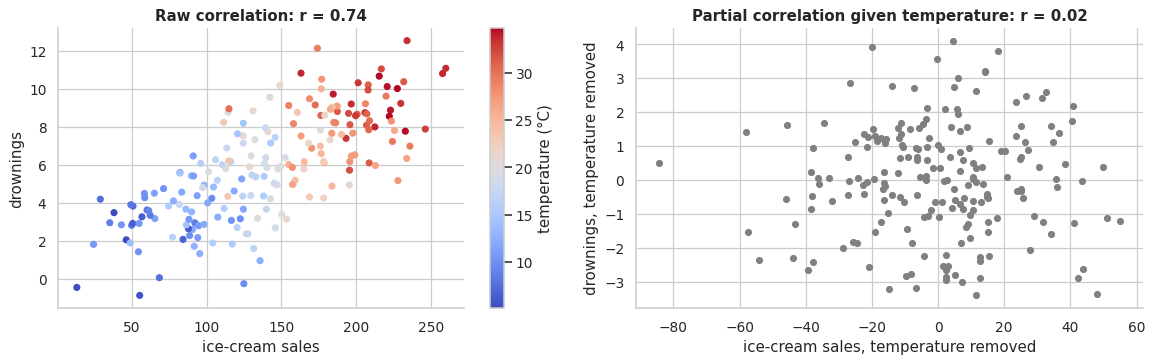

In [6]:
temp = rng.uniform(5, 35, 200)
ice = 20 + 6 * temp + rng.normal(0, 25, 200)                  # ice-cream sales depend on temperature
drown = 1 + .25 * temp + rng.normal(0, 1.6, 200)              # drownings depend on temperature — NOT on ice cream
resid = lambda v: v - np.polyval(np.polyfit(temp, v, 1), temp)               # what is left after removing the linear effect of temperature
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
sc = a1.scatter(ice, drown, c=temp, cmap="coolwarm", s=22); plt.colorbar(sc, ax=a1, label="temperature (°C)")
a1.set(xlabel="ice-cream sales", ylabel="drownings", title=f"Raw correlation: r = {np.corrcoef(ice, drown)[0, 1]:.2f}")
a2.scatter(resid(ice), resid(drown), s=22, color="grey")
a2.set(xlabel="ice-cream sales, temperature removed", ylabel="drownings, temperature removed", title=f"Partial correlation given temperature: r = {np.corrcoef(resid(ice), resid(drown))[0, 1]:.2f}")
plt.tight_layout(); plt.show()

**Reading the figure.** The colour reveals the mechanism: hot days (red) have high values of *both* variables. Once temperature is removed, nothing is left. Banning ice cream would not save a single swimmer. Partial correlation only helps for confounders you have **measured** — the general cure is an experiment (Module 8).

---
## 5. The least-squares line

Correlation is symmetric; **regression** is directional: we model the conditional mean of an outcome $y$ as a linear function of a predictor $x$,

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \sim N(0,\sigma^2)\ \text{independent}.$$

**Ordinary least squares (OLS)** chooses the line that minimises the sum of squared vertical distances (residuals) $\;SSE(b_0,b_1)=\sum_i (y_i-b_0-b_1x_i)^2$. Setting the derivatives to zero gives

$$b_1=\frac{\sum(x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2}=r\,\frac{s_y}{s_x},\qquad b_0=\bar y-b_1\bar x .$$

So the slope is just the correlation rescaled into the units of the data, and the line always passes through $(\bar x,\bar y)$.

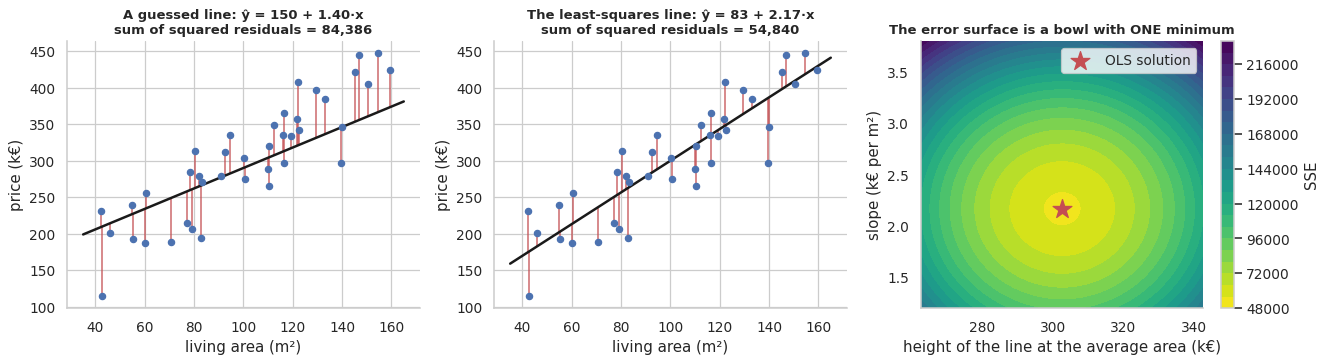

In [7]:
area = rng.uniform(40, 160, 40); price = 50 + 2.5 * area + rng.normal(0, 40, 40)             # flats: living area (m²) and price (k€)
b1, b0 = np.polyfit(area, price, 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (i0, s1, name) in zip(axes[:2], [(150, 1.4, "A guessed line"), (b0, b1, "The least-squares line")]):
    fit = i0 + s1 * area
    ax.vlines(area, fit, price, color=C[3], lw=1.3, alpha=.8); ax.scatter(area, price, color=C[0], s=25, zorder=3)
    xx = np.array([35, 165]); ax.plot(xx, i0 + s1 * xx, color="k", lw=2)
    ax.set(xlabel="living area (m²)", ylabel="price (k€)", title=f"{name}: ŷ = {i0:.0f} + {s1:.2f}·x\nsum of squared residuals = {((price - fit) ** 2).sum():,.0f}"); ax.title.set_fontsize(10.5)
A, B = np.meshgrid(np.linspace(price.mean() - 40, price.mean() + 40, 120), np.linspace(1.2, 3.8, 120))       # A = height of the line at x̄, B = slope
SSE = ((price[:, None, None] - A - B * (area - area.mean())[:, None, None]) ** 2).sum(axis=0)
cs = axes[2].contourf(A, B, SSE, levels=25, cmap="viridis_r"); plt.colorbar(cs, ax=axes[2], label="SSE")
axes[2].scatter(price.mean(), b1, marker="*", s=250, color=C[3], zorder=3, label="OLS solution")
axes[2].set(xlabel="height of the line at the average area (k€)", ylabel="slope (k€ per m²)", title="The error surface is a bowl with ONE minimum"); axes[2].title.set_fontsize(10.5); axes[2].legend()
plt.tight_layout(); plt.show()

**Reading the figure.** Red segments are the residuals. Any line can be scored by its sum of squared residuals; the right panel shows that score for *every* combination of height and slope — a smooth bowl. OLS jumps straight to the bottom via the formulas above. **Why squares?** They make the maths easy (unique closed-form solution), correspond to maximum likelihood under normal errors (Module 5), and estimate the conditional *mean*. Their price: sensitivity to outliers.

---
## 6. Reading the regression output

In [8]:
flats = pd.DataFrame({"area": area, "price": price})
model = smf.ols("price ~ area", data=flats).fit()
print(model.summary().tables[1])
print(f"\nR² = {model.rsquared:.3f}    residual standard error = {np.sqrt(model.mse_resid):.1f} k€    n = {int(model.nobs)}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     83.1537     19.700      4.221      0.000      43.274     123.034
area           2.1681      0.185     11.698      0.000       1.793       2.543

R² = 0.783    residual standard error = 38.0 k€    n = 40


| Piece | Meaning |
|---|---|
| `area` **coef** | **slope** $b_1$: each additional m² goes with a price that is on average $b_1$ k€ higher. *The* number of interest. |
| `Intercept` | predicted price at area = 0 — an extrapolation far outside the data, usually meaningless on its own. (Centre $x$ if you want an interpretable intercept.) |
| **std err** | standard error of the estimate: $\operatorname{SE}(b_1)=\dfrac{s_e}{s_x\sqrt{n-1}}$ → more data, less noise, *wider spread of x* all make the slope more precise. |
| **t**, **P>\|t\|** | test of $H_0\!:\beta_1=0$ ("no linear relationship") — identical to the test of $r=0$. |
| **[0.025 0.975]** | 95 % confidence interval for the coefficient. |
| **$R^2$** | share of the variance of $y$ explained by the line (next section). |
| **residual standard error** $s_e$ | typical size of a residual, in units of $y$ — often more useful than $R^2$: "predictions are typically off by ± $s_e$". |

---
## 7. $R^2$ — how much does the line explain?

Exactly as in ANOVA (Module 7) the total variation splits into an explained and an unexplained part:

$$\underbrace{\sum(y_i-\bar y)^2}_{SST}=\underbrace{\sum(\hat y_i-\bar y)^2}_{SSR\ (\text{explained})}+\underbrace{\sum(y_i-\hat y_i)^2}_{SSE\ (\text{residual})},\qquad R^2=1-\frac{SSE}{SST}=r^2 .$$

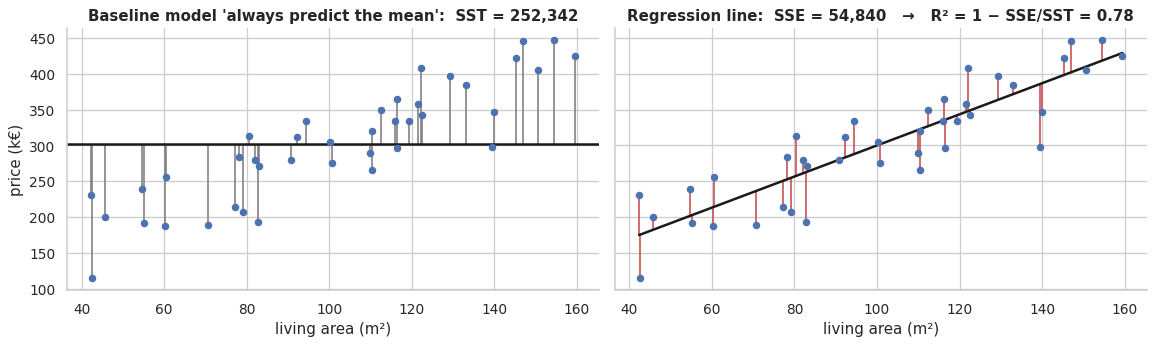

In [9]:
fitted = model.fittedvalues.values; SST, SSE = ((price - price.mean()) ** 2).sum(), ((price - fitted) ** 2).sum()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
a1.vlines(area, price.mean(), price, color="grey", lw=1.3); a1.axhline(price.mean(), color="k", lw=2); a1.scatter(area, price, color=C[0], s=25, zorder=3)
a1.set(title=f"Baseline model 'always predict the mean':  SST = {SST:,.0f}", xlabel="living area (m²)", ylabel="price (k€)")
a2.vlines(area, fitted, price, color=C[3], lw=1.3); a2.plot(np.sort(area), fitted[np.argsort(area)], color="k", lw=2); a2.scatter(area, price, color=C[0], s=25, zorder=3)
a2.set(title=f"Regression line:  SSE = {SSE:,.0f}   →   R² = 1 − SSE/SST = {1 - SSE / SST:.2f}", xlabel="living area (m²)")
plt.tight_layout(); plt.show()

**Use $R^2$ with care.** It measures how much better the line predicts than the plain mean — nothing more. A high $R^2$ does not prove the model is correct (Anscombe, Module 1!), a low $R^2$ does not make a slope useless (a drug effect can be real and important even if most of the variation between patients has other causes), and $R^2$ can be inflated simply by sampling a wider range of $x$.

---
## 8. Two kinds of uncertainty — confidence band vs. prediction band

* **Confidence band** — where is the *true regression line* (the mean of $y$ at a given $x$)? Narrowest at $\bar x$, wider towards the edges, because a small error in the slope matters more far from the centre.
* **Prediction band** — where will a *single new observation* fall? It adds the irreducible noise $\sigma^2$ and therefore never shrinks below about $\pm2s_e$, no matter how much data you collect.

$$\operatorname{SE}_{mean}(x_0)=s_e\sqrt{\frac1n+\frac{(x_0-\bar x)^2}{\sum(x_i-\bar x)^2}},\qquad \operatorname{SE}_{pred}(x_0)=s_e\sqrt{1+\frac1n+\frac{(x_0-\bar x)^2}{\sum(x_i-\bar x)^2}}$$

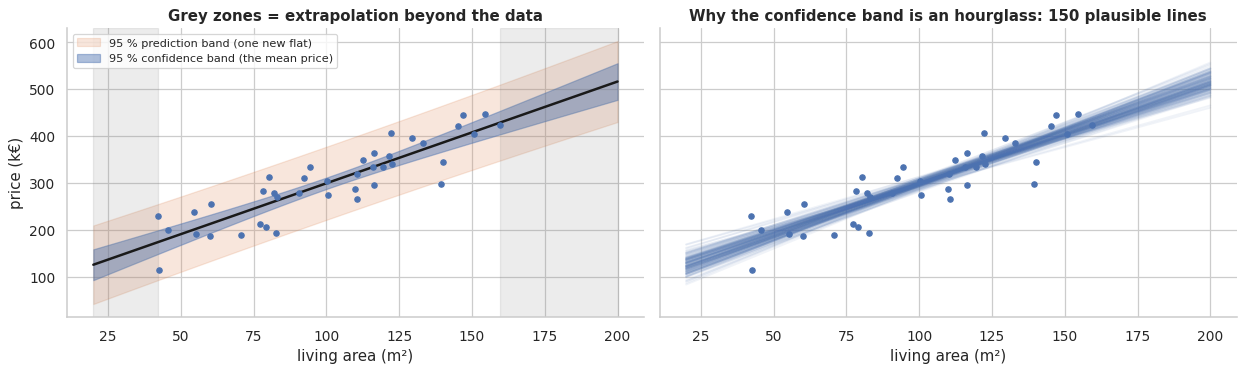

In [10]:
grid = pd.DataFrame({"area": np.linspace(20, 200, 100)})
pred = model.get_prediction(grid).summary_frame(alpha=.05)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.3), sharey=True)
a1.fill_between(grid.area, pred.obs_ci_lower, pred.obs_ci_upper, color=C[1], alpha=.2, label="95 % prediction band (one new flat)")
a1.fill_between(grid.area, pred.mean_ci_lower, pred.mean_ci_upper, color=C[0], alpha=.45, label="95 % confidence band (the mean price)")
a1.plot(grid.area, pred["mean"], color="k", lw=2); a1.scatter(area, price, s=18, color=C[0], zorder=3)
a1.axvspan(20, area.min(), color="grey", alpha=.15); a1.axvspan(area.max(), 200, color="grey", alpha=.15)
a1.set(xlabel="living area (m²)", ylabel="price (k€)", title="Grey zones = extrapolation beyond the data"); a1.legend(loc="upper left", fontsize=9)
for _ in range(150):                                                         # refit the line on 150 bootstrap resamples of the flats
    i = rng.integers(0, area.size, area.size); s, c = np.polyfit(area[i], price[i], 1); a2.plot(grid.area, c + s * grid.area, color=C[0], alpha=.08)
a2.scatter(area, price, s=18, color=C[0], zorder=3); a2.set(xlabel="living area (m²)", title="Why the confidence band is an hourglass: 150 plausible lines")
plt.tight_layout(); plt.show()

**Extrapolation warning.** The bands assume that the *straight-line model* holds. Inside the data range you can check this; outside you cannot. The formulas will happily return a narrow-looking interval for a 400 m² flat — the true uncertainty there is unknown, because nothing tells you the relationship stays linear.

---
## 9. Diagnostics — is the model adequate?

The inference above rests on four assumptions, easily remembered as **LINE**:

| | Assumption | Violated when … | Consequence | Typical fix |
|---|---|---|---|---|
| **L** | **L**inear relationship | curved pattern in residuals vs. fitted | biased predictions, wrong conclusions | transform $x$ or $y$, add polynomial terms |
| **I** | **I**ndependent errors | time series, clusters, repeated measures | standard errors too small | time-series / mixed models (Module 13) |
| **N** | **N**ormal errors | Q–Q plot bends | matters mainly for small $n$ and prediction intervals | transform $y$; bootstrap |
| **E** | **E**qual variance (homoscedasticity) | funnel shape | wrong SEs and intervals | log-transform $y$; robust SEs; weighted LS |

All of them concern the **residuals**, not the raw variables. The function `diagnostic_plots` (defined in the setup cell) draws the four standard views. Top row: a well-behaved model. Bottom row: a straight line forced onto data that is curved *and* has growing spread.

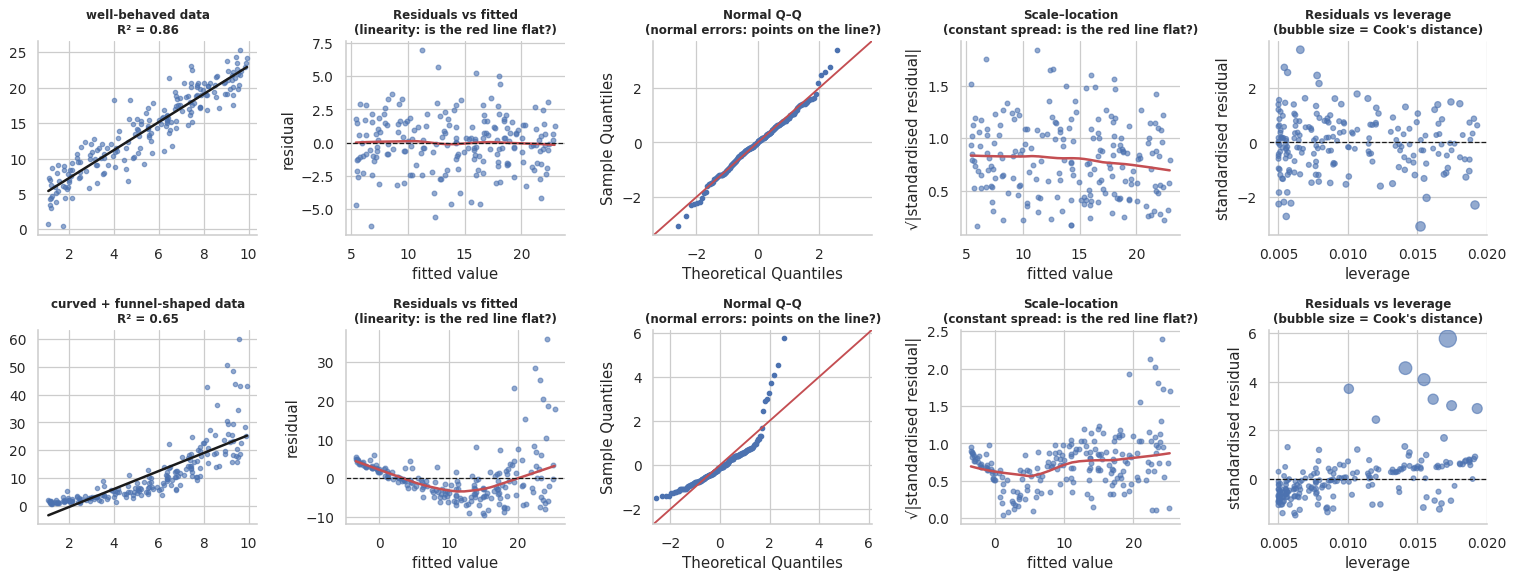

In [11]:
n = 200; x = rng.uniform(1, 10, n)
good = pd.DataFrame({"x": x, "y": 3 + 2 * x + rng.normal(0, 2, n)})
bad = pd.DataFrame({"x": x, "y": np.exp(.35 * x) * rng.lognormal(0, .35, n)})
fig, axes = plt.subplots(2, 5, figsize=(17, 6.6))
for row, (d, name) in zip(axes, [(good, "well-behaved data"), (bad, "curved + funnel-shaped data")]):
    m = smf.ols("y ~ x", data=d).fit()
    row[0].scatter(d.x, d.y, s=12, alpha=.6); row[0].plot(np.sort(d.x), m.fittedvalues.values[np.argsort(d.x)], color="k", lw=2)
    row[0].set_title(f"{name}\nR² = {m.rsquared:.2f}", fontsize=9.5); diagnostic_plots(m, row[1:])
plt.tight_layout(); plt.show()

**Reading the figure.** *Top row:* residuals form a structureless horizontal band, the Q–Q points follow the line, the scale–location line is flat, no point combines high leverage with a large residual. *Bottom row:* despite a respectable $R^2$ the residual plot shows a clear **U-shape** (non-linearity) and a **funnel** (variance grows with the fitted value), the Q–Q plot bends upwards (right-skewed errors).

**The repair:** the data were generated by a *multiplicative* process, $y = e^{0.35x}\cdot\text{noise}$. Taking logs turns it into an additive, linear one: $\log y = 0.35x+\log(\text{noise})$.

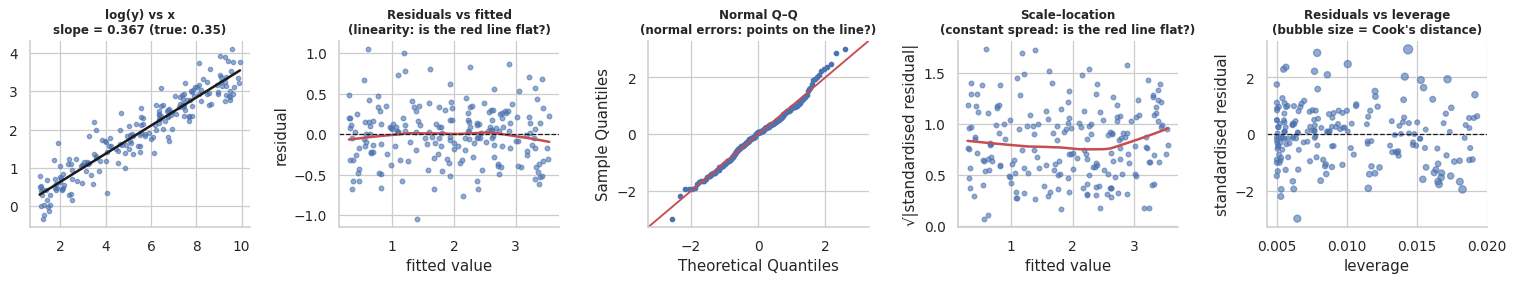

In [12]:
m_log = smf.ols("np.log(y) ~ x", data=bad).fit()
fig, axes = plt.subplots(1, 5, figsize=(17, 3.3))
axes[0].scatter(bad.x, np.log(bad.y), s=12, alpha=.6); axes[0].plot(np.sort(bad.x), m_log.fittedvalues.values[np.argsort(bad.x)], color="k", lw=2)
axes[0].set_title(f"log(y) vs x\nslope = {m_log.params['x']:.3f} (true: 0.35)", fontsize=9.5); diagnostic_plots(m_log, axes[1:])
plt.tight_layout(); plt.show()

After the log-transformation all four diagnostics look clean. **Interpretation of a log-outcome model:** a one-unit increase in $x$ multiplies $y$ by $e^{b_1}$ — here ≈ $e^{0.35}=1.42$, i.e. **+42 % per unit**. (If *both* variables are logged, the slope is an *elasticity*: % change in $y$ per 1 % change in $x$.)

---
## 10. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 9.1 — *Pearson vs. Spearman*: Does advertising spend go with revenue? (Marketing)

A marketing team has spend and attributed revenue for 36 campaigns. One of them was a national TV campaign with a huge budget and a disappointing return.

**Tasks**
1. Plot the data. Compute Pearson's $r$ and Spearman's $\rho$ for all campaigns.
2. Recompute both without the TV campaign. Which coefficient is more stable?
3. Compute a bootstrap 95 % CI for Pearson's $r$ among the 35 regular campaigns (resample *pairs*).
4. What do you report — and what do you say about the TV campaign?

In [13]:
g = np.random.default_rng(901)
spend = g.uniform(5, 60, 35); revenue = 40 + 2.2 * spend + g.normal(0, 28, 35)
ads = pd.DataFrame({"campaign": [f"C{i:02d}" for i in range(1, 36)] + ["TV"],
                    "spend_k": np.append(spend, 240).round(1), "revenue_k": np.append(revenue, 150).round(1)})
ads.tail(3)

,campaign,spend_k,revenue_k
33,C34,35.2,162.0
34,C35,46.6,131.8
35,TV,240.0,150.0


In [14]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/09_correlation_simple_regression_solutions.ipynb`.

### ✍️ Exercise 9.2 — *Confounding & partial correlation*: Do firefighters cause damage? (Public safety)

A city's data on 300 fires shows: the more firefighters were sent, the higher the damage. A councillor proposes to cut costs *and* damage by sending fewer firefighters.

**Tasks**
1. Compute the raw correlation between firefighters and damage and plot it, colouring points by fire size.
2. Compute the partial correlation controlling for fire size (residual method).
3. Explain the result to the councillor in two sentences.

In [15]:
g = np.random.default_rng(902)
fire_size = g.gamma(2, 2, 300)
firefighters = np.round(3 + 2.5 * fire_size + g.normal(0, 2, 300)).clip(2)
damage = 10 + 12 * fire_size - 1.5 * firefighters + g.normal(0, 8, 300)
fires = pd.DataFrame({"fire_size": fire_size.round(2), "firefighters": firefighters, "damage_k": damage.round(1)})
fires.corr().round(2)

,fire_size,firefighters,damage_k
fire_size,1.00,0.96,0.93
firefighters,0.96,1.00,0.86
damage_k,0.93,0.86,1.00


In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/09_correlation_simple_regression_solutions.ipynb`.

### ✍️ Exercise 9.3 — *Fitting & interpreting a regression line*: What is a square metre worth? (Real estate)

You have asking prices and living areas of 120 flats in one city district.

**Tasks**
1. Compute slope and intercept **by hand** from the formulas, then fit the model with `smf.ols` and compare.
2. Interpret slope, intercept, $R^2$ and the residual standard error in plain language. Give the 95 % CI of the slope.
3. A 95 m² flat is offered for €420k. Compute the 95 % **prediction interval** for such a flat. Is it overpriced?

In [17]:
g = np.random.default_rng(903)
area = g.uniform(45, 180, 120).round(0)
homes = pd.DataFrame({"area_m2": area, "price_k": (35 + 3.1 * area + g.normal(0, 45, 120)).round(0)})
homes.describe().round(1)

,area_m2,price_k
count,120.0,120.0
mean,116.2,398.0
std,37.3,121.9
min,46.0,119.0
25%,81.0,292.5
50%,120.0,417.0
75%,147.5,493.2
max,177.0,633.0


In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/09_correlation_simple_regression_solutions.ipynb`.

### ✍️ Exercise 9.4 — *Prediction & extrapolation*: How much gas will the city need tomorrow? (Energy utility)

A municipal utility models daily gas demand (MWh) during the heating season as a function of the mean outdoor temperature.

**Tasks**
1. Fit the model and interpret the slope.
2. Tomorrow's forecast is **−2 °C**. Report the 95 % confidence interval for the mean demand and the 95 % prediction interval. Which one matters for capacity planning?
3. A cold snap of **−15 °C** is forecast for next week, and someone also asks about a summer day of **+25 °C**. What does the model predict — and should you trust it?
4. Plot data, line and both bands from −16 to +26 °C and shade the region without data.

In [19]:
g = np.random.default_rng(904)
temp = g.uniform(-4, 16, 90).round(1)
gas = pd.DataFrame({"temp_c": temp, "demand_mwh": (520 - 21 * temp + g.normal(0, 28, 90)).round(0)})
gas.describe().round(1)

,temp_c,demand_mwh
count,90.0,90.0
mean,6.4,388.2
std,5.7,121.4
min,-3.6,185.0
25%,1.8,281.0
50%,5.8,395.5
75%,11.0,482.5
max,15.7,618.0


In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/09_correlation_simple_regression_solutions.ipynb`.

### ✍️ Exercise 9.5 — *Diagnostics & transformation*: Stopping distance of a car (Road safety)

Test drives recorded the total stopping distance (reaction + braking) at various speeds.

**Tasks**
1. Fit `distance_m ~ speed_kmh` and draw the four diagnostic plots (`diagnostic_plots(model, axes)` from the setup cell). Which assumptions are violated?
2. Fit two alternatives: (a) a quadratic model `distance_m ~ speed_kmh + I(speed_kmh**2)`; (b) a log–log model. Inspect their diagnostics.
3. Compare the three models' predictions at 30, 100 and 160 km/h. What does the straight line predict at 10 km/h?
4. Physics says: distance = reaction distance ($\propto v$) + braking distance ($\propto v^2$). Which model matches the physics, and how do you interpret the log–log slope?

In [21]:
g = np.random.default_rng(905)
speed = g.uniform(20, 130, 150).round(0); v = speed / 3.6
brake = pd.DataFrame({"speed_kmh": speed, "distance_m": ((v * 1.0 + v ** 2 / (2 * 7.0)) * g.lognormal(0, .12, 150)).round(1)})
brake.describe().round(1)

,speed_kmh,distance_m
count,150.0,150.0
mean,75.3,57.4
std,30.6,35.9
min,22.0,9.7
25%,49.0,26.7
50%,75.5,53.6
75%,100.0,83.2
max,130.0,166.4


In [22]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/09_correlation_simple_regression_solutions.ipynb`.

---
## 11. 🔑 Key takeaways

* **Pearson's $r$** measures *linear* association; **Spearman's $\rho$** monotonic association on ranks. Plot first — non-linearity, outliers, range restriction and mixed groups all fool $r$.
* **Correlation is not causation.** Think about common causes; partial correlation adjusts only for *measured* confounders.
* The **OLS line** minimises squared residuals: $b_1=r\,s_y/s_x$, and it passes through $(\bar x,\bar y)$.
* Report the **slope with its CI** and the **residual standard error**; treat $R^2$ as a description, not a quality seal.
* **Confidence band** = uncertainty about the mean; **prediction band** = uncertainty about one new case (much wider, never vanishes). Do not extrapolate.
* Check **LINE** with residual plots. Curvature or funnels → transform (often $\log$), which also changes the interpretation to *percentage* effects.

### Cheat sheet
| Task | Code |
|---|---|
| correlations | `stats.pearsonr(x, y)`, `stats.spearmanr(x, y)`, `stats.kendalltau(x, y)`, `df.corr(method="spearman")` |
| fit a line | `m = smf.ols("y ~ x", data=df).fit()`; `m.summary()` |
| coefficients, CIs, $R^2$, $s_e$ | `m.params`, `m.conf_int()`, `m.rsquared`, `np.sqrt(m.mse_resid)` |
| predictions with both intervals | `m.get_prediction(new_df).summary_frame(alpha=.05)` → `mean_ci_*`, `obs_ci_*` |
| residuals, leverage, Cook's distance | `m.resid`, `m.get_influence().hat_matrix_diag`, `m.get_influence().cooks_distance[0]` |
| transformations in formulas | `"np.log(y) ~ x"`, `"y ~ x + I(x**2)"` |

**Next:** Module 10 — several predictors at once: multiple regression, categorical predictors, interactions, diagnostics and regularisation.